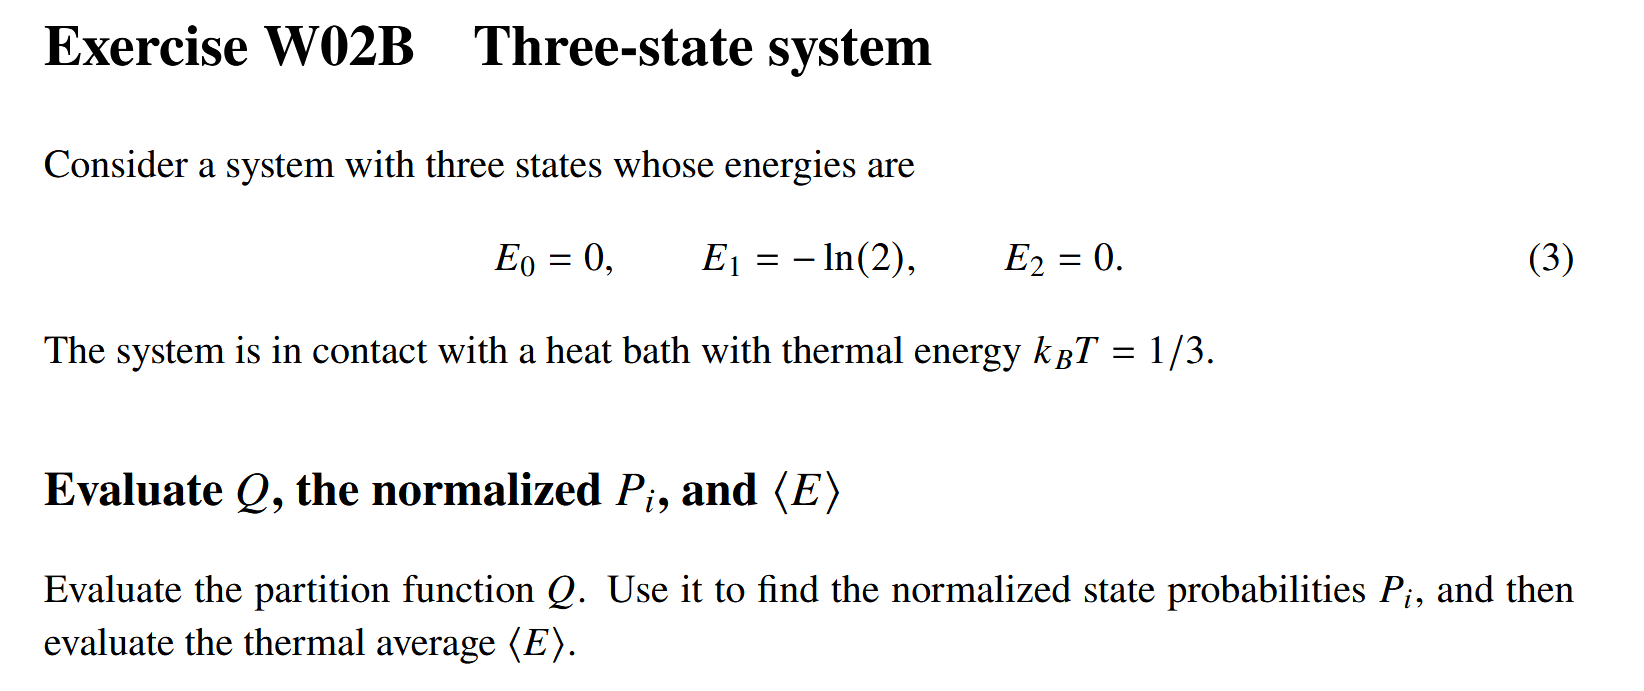

In [29]:
import numpy as np
import matplotlib.pyplot as plt 

E = np.array([0, -np.log(2), 0])
kbt = 1/3
Q = np.sum(np.exp(-E/kbt))
P = 1/Q * np.exp(-E/kbt)

for j,i in enumerate(P): 
    print(f"P_{j} = {i:.2g}")

P_0 = 0.1
P_1 = 0.8
P_2 = 0.1


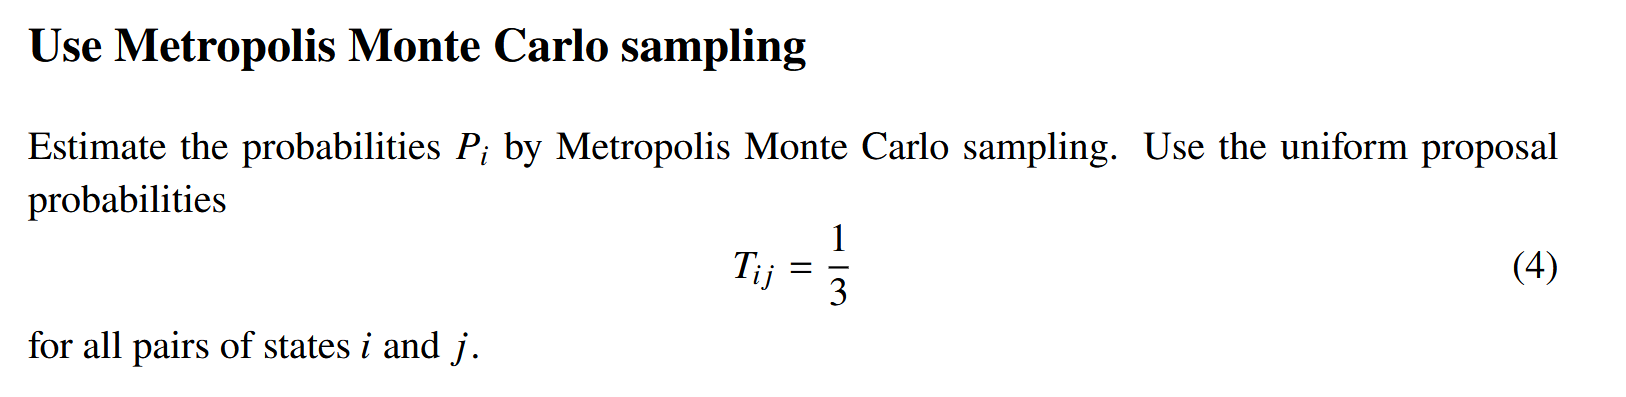

In [ ]:
class Metropolis:
    def __init__(self, T, energies, initial, kbT=1/3):
        self.T = T
        self.energies = energies
        self.state = initial
        self.kbT = kbT

    def propse(self):
        """
        Looks at current state, and chooses a new index to jump to from T
        """
        i = self.state
        return np.random.choice(range(len(self.energies)), p=self.T[i])

    def step(self):
        """
        Looks at a proposed state and calculates the acceptance from 2.32
        Then chooses the next state. 
        """
        j = self.propse()
        A = min(1, self._exp(self.state, j))
        if np.random.rand() < A: 
            self.state = j

    def run_simulation(self, n=100_000):
        """
        Run simulation 
        """
        states = [self.state]
        for _ in range(n):
            self.step()
            states.append(self.state)

        return states

    def _exp(self, i, j):
        """
        Calculates the ratio P_j/P_i
        """
        return np.exp(-1/self.kbT * (self.energies[j]-self.energies[i]))

T = np.ones((3,3))*1/3

sim = Metropolis(T, E, 0)
out = sim.run_simulation()

counts = np.bincount(out)
P = counts / len(out)

print(f"Estimated P_i: {[float(f'{x:.3f}') for x in P]}")

Estimated P_i: [0.1, 0.801, 0.099]


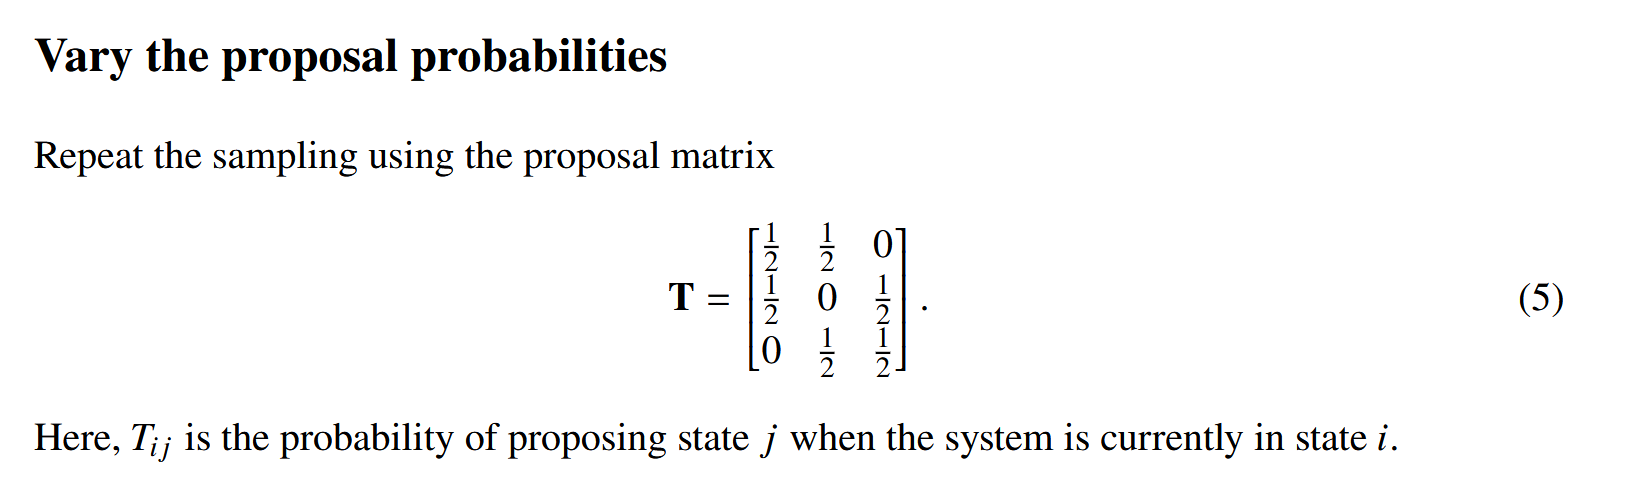

In [31]:
T2 = np.array([[0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]])

sim = Metropolis(T2, E, 0)
out = sim.run_simulation()

counts = np.bincount(out)
P = counts / len(out)

print(f"Estimated P_i: {[float(f'{x:.3f}') for x in P]}")

Estimated P_i: [0.102, 0.803, 0.095]


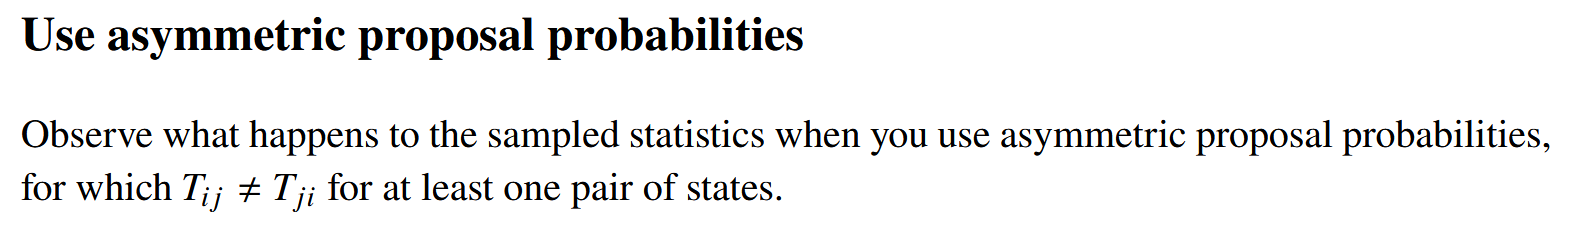

In [32]:
T3 = np.array([[0.7, 0.3, 0], [0.1, 0, 0.9], [0, 0.1, 0.9]])

sim = Metropolis(T3, E, 0)
out = sim.run_simulation()

counts = np.bincount(out)
P = counts / len(out)

print(f"Estimated P_i: {[float(f'{x:.3f}') for x in P]}")

Estimated P_i: [0.021, 0.465, 0.514]
